# Regional influence: leave-one-region-out sensitivity

Spatial colocalization returns a single number per receptor or cell type — the correlation across all brain regions. But the cortex is not homogeneous: some regions may drive the colocalization strongly while others contribute little or even suppress it.

**Regional influence** asks: *how much does the reported colocalization change when each region is excluded?*

Formally, for each region $i$:
$$\text{influence}_i = \rho_{\text{full}} - \rho_{\text{LOO}(-i)}$$

A large positive value means the region inflates the colocalization; a large negative value means it suppresses it. Regions near zero are not influential.

This is **not** Cook's distance or DFFITS, which flag statistical outliers. Regional influence asks a different question: *which brain regions drive the reported scientific effect?*

NiSpace implements `regional_influence()` with two engines:
- **Analytic** (`engine="analytic"`): closed-form case-deletion identities (Sherman-Morrison downdate for MLR, running-sum downdate for Pearson/Spearman). Numerically identical to a real refit, but O(n) total instead of O(n²). Works for `pearson`, `spearman`, `partialpearson`, `partialspearman`, `mlr`.
- **Bruteforce** (`engine="bruteforce"`): reruns `colocalize()` with each region deleted. Works for any method except `lasso`, `ridge`, `elasticnet`.
- **`engine="auto"`** (default): picks analytic when available, bruteforce otherwise.

> **Prerequisite**: this notebook loads pre-computed NiSpace objects saved in
> [intro02](intro02_nispace_intro.ipynb) and [intro10](intro10_xsea.ipynb).
> Run those two notebooks first to generate `intro02_nsp.pkl.blosc` and `intro10_nsp.pkl.blosc`.

In [1]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
from nispace.api import NiSpace
from nispace.plotting import brainplot

## Load pre-computed NiSpace objects

We load two NiSpace objects with existing colocalization and permutation results:
- **nsp02**: pain map vs. PET receptor maps (Spearman, Yan200) — from [intro02](intro02_nispace_intro.ipynb)
- **nsp10**: pain map vs. mRNA cell type markers, XSEA (Spearman, Yan100+TianS1) — from [intro10](intro10_xsea.ipynb)

In [5]:
nsp02 = NiSpace.from_pickle("intro02_nsp.pkl.blosc")
print("nsp02 — pain × PET (Yan200):")
print(nsp02.get_colocalizations().loc["Pain"].sort_values(ascending=False).head(5))

print()
nsp10 = NiSpace.from_pickle("intro10_nsp.pkl.blosc")
print("nsp10 — pain × mRNA XSEA (Yan100+TianS1):")
print(nsp10.get_colocalizations().loc["Pain"].sort_values(ascending=False).head(5))

nsp02 — pain × PET (Yan200):
INFO | 12/07/26 01:40:27 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 
set                          map                                                   
Noradrenaline/Acetylcholine  target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017    0.422783
Opioids/Endocannabinoids     target-KOR_tracer-ly2795050_n-28_dx-hc_pub-vijay2018      0.335397
Noradrenaline/Acetylcholine  target-NET_tracer-mrb_n-10_dx-hc_pub-hesse2017            0.288889
Histamine                    target-H3_tracer-gsk189254_n-8_dx-hc_pub-gallezot2017     0.273213
Glutamate                    target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019      0.180214
Name: Pain, dtype: float32

nsp10 — pain × mRNA XSEA (Yan100+TianS1):
INFO | 12/07/26 01:40:27 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 
Mic

## Example 1: standard colocalization (PET receptors)

For `spearman` colocalization, `regional_influence()` produces one influence profile per X-map (receptor). We ask: which brain regions drive the colocalization between the pain map and the top receptor (VAChT — the vesicular acetylcholine transporter)?

In [6]:
# Compute regional influence (uses analytic engine automatically for spearman)
nsp02.regional_influence()

# Retrieve results: dict keyed by X-map label (receptor), each value (n_Y × n_parcels)
ri02 = nsp02.get_regional_influence()
print(f"Type: {type(ri02)}")
print(f"Keys (first 3): {list(ri02.keys())[:3]}")
print(f"Shape per receptor: {next(iter(ri02.values())).shape}  (n_Y × n_parcels)")

INFO | 12/07/26 01:40:38 | nispace.api: *** NiSpace.regional_influence() - Estimating regional influence. ***


Regional influence (spearman, analytic, 4 proc): 100%|██████████| 1/1 [00:00<00:00, 86.06it/s]


Type: <class 'dict'>
Keys (first 3): [('General', 'target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023'), ('General', 'target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023'), ('General', 'target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016')]
Shape per receptor: (1, 200)  (n_Y × n_parcels)


INFO | 12/07/26 01:41:03 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA  | X_REDUCTION | Y_TRANSFORM | 
| spearman | False | False       | False       | 
Top receptor: ('Noradrenaline/Acetylcholine', 'target-VAChT_tracer-feobv_n-18_dx-hc_pub-aghourian2017')
WARNING | 12/07/26 01:41:03 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!
INFO | 12/07/26 01:41:03 | nispace.core.parcellation: Building cortex Parcellation for 'Yan200' from library. DOI: 10.1016/j.neuroimage.2023.120010
INFO | 12/07/26 01:41:03 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsLR, fsaverage
INFO | 12/07/26 01:41:03 | nispace.core.parcellation: Parcellation 'Yan200': validation passed.
INFO | 12/07/26 01:41:03 | nispace.plotting: brainplot: threshold='auto' → 8.305642040795647e-06
INFO | 12/07/26 01:41:03 | nispace.core.parcellation: Lazy-loading parcellation image for space 'MNI152NLin2009cAsy

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

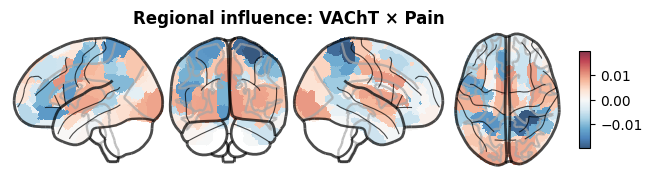

In [8]:
# Identify the top receptor by |rho|
top_pet = nsp02.get_colocalizations().loc["Pain"].abs().idxmax()
print(f"Top receptor: {top_pet}")

# Plot the influence map for that receptor
# Positive = region inflates the colocalization; negative = region suppresses it
brainplot(
    ri02[top_pet],
    parcellation="Yan200",
    title="Regional influence: VAChT × Pain",
)

In [9]:
# Show top-5 and bottom-5 regions by influence
ri_series = ri02[top_pet].squeeze()  # (n_parcels,) Series
print("Regions most inflating the VAChT colocalization (top 5):")
print(ri_series.sort_values(ascending=False).head(5).to_string())
print("\nRegions most suppressing it (bottom 5):")
print(ri_series.sort_values().head(5).to_string())

Regions most inflating the VAChT colocalization (top 5):
hemi-L_div-SalVenAttnB_lab-FrMed    0.010450
hemi-R_div-SalVenAttnB_lab-FrMed    0.010024
hemi-R_div-VisualB_lab-Striate+2    0.009921
hemi-R_div-SalVenAttnB_lab-Ins      0.009401
hemi-R_div-SomMotB_lab-Ins          0.009198

Regions most suppressing it (bottom 5):
hemi-R_div-SomMotA_lab-8          -0.019820
hemi-R_div-DorsAttnB_lab-SPL      -0.018040
hemi-L_div-DorsAttnB_lab-SPL      -0.013947
hemi-L_div-SomMotA_lab-8          -0.013549
hemi-L_div-SalVenAttnB_lab-PrCv   -0.013505


## Example 2: XSEA (cell type enrichment)

For XSEA, `regional_influence()` picks up the `xsea=True` setting automatically from the last `colocalize()` call. The result dict is keyed by **cell type set labels** rather than individual gene labels.

In [10]:
# Regional influence for XSEA (auto picks up xsea=True from last colocalize)
nsp10.regional_influence()

ri10 = nsp10.get_regional_influence()
print(f"Type: {type(ri10)}")
print(f"Keys (cell types): {list(ri10.keys())}")

INFO | 12/07/26 01:42:13 | nispace.api: *** NiSpace.regional_influence() - Estimating regional influence. ***


Regional influence (spearman, analytic, 4 proc): 100%|██████████| 1/1 [00:00<00:00, 1700.85it/s]


Type: <class 'dict'>
Keys (cell types): ['Ex1 CortProject (L2/3)', 'Ex2 Granule (L3/4)', 'Ex3 Granule (L4)', 'Ex4 SubcortProject (L4)', 'Ex5 SubcortProject (L4-6)', 'Ex6 SubcortProject (L5-6)', 'Ex7 Corticothalamic', 'Ex8 Corticothalamic (L6)', 'In1 VIP+RELN+NDNF+ (L1/2)', 'In2 VIP+RELN-NDNF- (L6)', 'In3 VIP+RELN+NDNF- (L6)', 'In4 VIP-RELN+NDNF+ (L1-3)', 'In5 CCK+NOS1+CALB2+ (L2/3)', 'In6 PVALB+CRHBP+ (L4/5)', 'In7 SST+CALB1+NPY+ (L5/6)', 'In8 SST+NOS1+ (L6)', 'Astrocyte', 'Endothelial', 'Developing-quiescent', 'Developing-replicating', 'Microglia', 'Other Neurons', 'OPC', 'Oligodendrocyte']


INFO | 12/07/26 01:42:22 | nispace.api: Returning colocalizations: 
| METHOD   | XSEA | X_REDUCTION | Y_TRANSFORM | 
| spearman | True | False       | False       | 
Top cell type: Microglia
WARNING | 12/07/26 01:42:22 | nispace.plotting: Brain plotting in NiSpace is experimental. If things look off, feel free to raise a GitHub issue!
INFO | 12/07/26 01:42:22 | nispace.core.parcellation: Building combined Parcellation 'Yan100+TianS1' from library.
INFO | 12/07/26 01:42:22 | nispace.core.parcellation:   Common MNI space(s) for combined: ['MNI152NLin2009cAsym', 'MNI152NLin6Asym'].
INFO | 12/07/26 01:42:22 | nispace.core.parcellation:   Merging 'Yan100' and 'TianS1' for space 'MNI152NLin2009cAsym'.
INFO | 12/07/26 01:42:22 | nispace.core.parcellation:   Merging 'Yan100' and 'TianS1' for space 'MNI152NLin6Asym'.
INFO | 12/07/26 01:42:22 | nispace.core.parcellation:   Fetching cx surface data for 'Yan100' in 'fsLR' (for spin tests).
INFO | 12/07/26 01:42:22 | nispace.core.parcellation:   Fe

(<Figure size 720x180 with 6 Axes>, [<Axes: >])

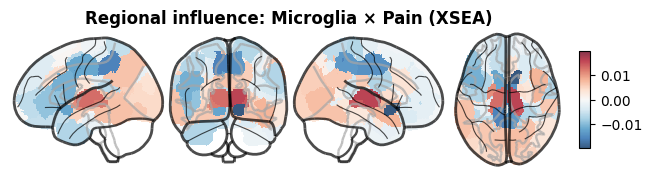

In [12]:
# Top cell type by |mean rho|
top_ct = nsp10.get_colocalizations().loc["Pain"].abs().idxmax()
print(f"Top cell type: {top_ct}")

brainplot(
    ri10[top_ct],
    parcellation="Yan100+TianS1",
    title=f"Regional influence: {top_ct} × Pain (XSEA)",
)

## Multi-Y pooling

Both examples above have a single Y map (the pain map), so the result is a (1 × n_parcels) DataFrame per receptor/set.

For multi-subject designs (n_Y > 1), each row of the result DataFrame corresponds to one subject's influence profile. `get_regional_influence(pooled="mean")` collapses across subjects, giving a single (1 × n_parcels) DataFrame per key:

```python
# Example: multi-subject — n_Y = number of subjects
nsp_multi.regional_influence()
ri_pooled = nsp_multi.get_regional_influence(pooled="mean")  # averages across subjects
```

Use `pooled="median"` for robustness to outlier subjects.

## Summary

- `nsp.regional_influence()` computes influence per region: how much does removing a region change the colocalization?
- `get_regional_influence()` returns a dict (per-pair methods like spearman) or a DataFrame (joint-model methods like mlr).
- `engine="auto"` picks the analytic closed-form for `pearson`/`spearman`/`partialpearson`/`partialspearman`/`mlr`, and bruteforce for all others.
- `lasso`, `ridge`, `elasticnet` are not supported (their closures fix the data size at fit time).
- XSEA is supported: influence reflects how each region shapes the set-level mean colocalization.
- For multi-subject data, use `get_regional_influence(pooled="mean")` to aggregate across subjects.